In [9]:
import pandas as pd
from datetime import datetime, date, timedelta, time
import requests

In [10]:
TOKEN = "72e6575c-9265-45d8-99bb-071bfac38e42"
config_path = "C:/Users/mpy/Market data retrieval/api_retrieval/config/config.yaml"

In [11]:
from config.config_loader import Config

In [12]:
from api_retrieval.markets.entsoe.entsoe_helper import EntsoeRetrieval

In [13]:
config = Config(config_path)

In [14]:
start_date = pd.Timestamp('2015-02-01 00:00', tz='Europe/Madrid')
end_date = pd.Timestamp('2025-08-31 23:59', tz='Europe/Madrid')

In [15]:
from entsoe import EntsoePandasClient

df = pd.DataFrame()

countries = ['ES']
client = EntsoePandasClient(api_key=TOKEN)
country = 'ES'  # Spain


In [18]:
for country in countries:
    df_country = client.query_load(country_code=country, start=pd.Timestamp(start_date), end=pd.Timestamp(end_date))
    df_country['country'] = country
    df_country.reset_index(names='datetime', inplace=True)
    # df_country['datetime'] = pd.to_datetime(df_country['datetime'])
    # df_country['datetime_utc'] = df_country['datetime'].dt.tz_convert('UTC')
    df = pd.concat([df, df_country], ignore_index=True)
df.rename(columns={'Actual Load': 'load'}, inplace=True)

In [19]:
df['datetime'].dt.year.unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype=int32)

In [20]:
# df[(df['datetime'].dt.date == date(2020, 1, 20)) & (df['load'] > 3.9e4)]

# dict_instant = {
#     '20 Jan 2020': datetime(2020, 1, 20).date(),
#     '8 Jan 2021': datetime(2021, 1, 8).date(),
#     '14 Jul 2022': datetime(2022, 7, 14).date(),
#     '24 Jan 2023': datetime(2023, 1, 24).date(),
#     '9 Jan 2024': datetime(2024, 1, 9).date(),
# }

# list_max_load = []

# for key, value in dict_instant.items():
#     max_load = df[df['datetime'].dt.date == value]['load'].max()
#     df_target_day = df[(df['datetime'].dt.date == value) & (df['load'] == max_load)]['datetime']
#     if not df_target_day.empty:
#         datetime_value = df_target_day.iloc[0]
#     else:
#         datetime_value = None
#     list_max_load.append((datetime_value))

# list_max_load

In [21]:
# calcular potencia media diaria de demanda

df_daily = df.groupby(df['datetime'].dt.date)['load'].mean().reset_index()
# df_daily.reset_index(names='datetime', inplace=True)
# df_daily['date'] = df_daily['datetime'].dt.date
# df_daily.drop(columns=['datetime'], inplace=True)
df_daily.columns = ['date', 'daily_avg']
df_daily

,date,daily_avg
0,2015-02-01,27251.291667
1,2015-02-02,32887.250000
2,2015-02-03,33646.916667
3,2015-02-04,34406.375000
4,2015-02-05,34069.869565
...,...,...
3860,2025-08-27,29943.416667
3861,2025-08-28,28128.208333
3862,2025-08-29,26927.041667
3863,2025-08-30,24753.875000


<Axes: title={'center': 'Hourly Demand Spain'}, xlabel='datetime'>

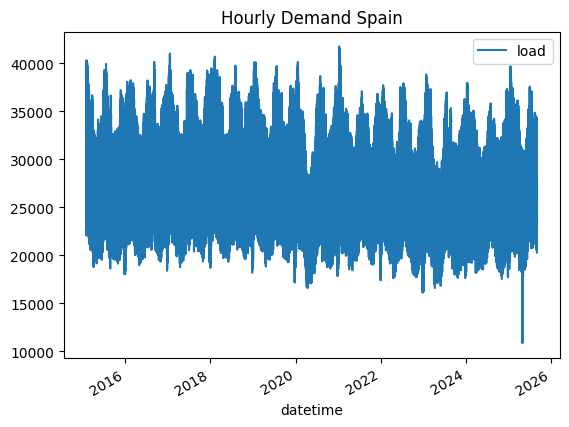

In [ ]:
# We calculate hourly demand, in case we have different resolution in the dataset
ds_hourly_demand = df.groupby([df['datetime'].dt.date, df['datetime'].dt.hour])['load'].mean()
df_hourly_demand = pd.DataFrame(ds_hourly_demand, columns=['load'])
df_hourly_demand.index.names = ['date', 'hour']
df_hourly_demand.reset_index(inplace=True)
df_hourly_demand['datetime'] = df_hourly_demand.apply(lambda row: datetime.combine(row['date'], time(row['hour'])), axis=1)

# ds_quarterly_demand = df_hourly_demand.groupby([df_hourly_demand['datetime'].dt.year, df_hourly_demand['datetime'].dt.quarter])['load'].sum()
# ds_quarterly_demand.index.names = ['year', 'quarter']
# df_quarterly_demand = pd.DataFrame(ds_quarterly_demand, columns=['load'])
# df_quarterly_demand.reset_index(inplace=True)
# df_quarterly_demand_pivot = df_quarterly_demand.pivot(index='quarter', columns='year', values='load')
# df_quarterly_demand.T.to_excel('quarterly_demand_ES.xlsx')

df_hourly_demand

In [23]:
# We are going to calculate the hour gaps in demand

# df_hourly_demand['load_shifted'] = df_hourly_demand['load'].shift(1)
# df_hourly_demand['hour_shifted'] = df_hourly_demand['datetime'].shift(1)
# df_hourly_demand['hour_gap'] = df_hourly_demand['hour_shifted'].dt.hour.astype(str) + '-' + df_hourly_demand['hour'].astype(str)
# df_hourly_demand['gap'] = df_hourly_demand['load'] - df_hourly_demand['load_shifted']
# df_hourly_demand['abs_gap'] = df_hourly_demand['gap'].abs()
# df_hourly_demand.dropna(subset=['gap'], inplace=True)
# df_hourly_demand.groupby([df_hourly_demand['datetime'].dt.year])['abs_gap'].describe()
# df_hourly_demand[df_hourly_demand['abs_gap'] > 13000]

In [24]:
# df.reset_index(names='datetime', inplace=True)
df['date'] = df['datetime'].dt.date
df['year'] = df['datetime'].dt.year
df['quarter'] = df['datetime'].dt.quarter
df['winter_summer'] = df['datetime'].dt.month.apply(lambda x: 'winter' if x in [10, 11, 12, 1, 2, 3] else 'summer')
df['hour'] = df['datetime'].dt.hour

df_demand_merged = pd.merge(df, df_daily, on='date', how='left')

df_demand_merged['normalized_load'] = df_demand_merged['load'] / df_demand_merged['daily_avg']
df_demand_merged['seasonal_year'] = df_demand_merged.apply(lambda row: row['year'] + 1 if row['quarter'] in [4] else row['year'], axis=1)

ds = df_demand_merged.groupby([df_demand_merged['seasonal_year'], df_demand_merged['winter_summer'], df_demand_merged['hour']])['normalized_load'].mean()

df_demand_target = pd.DataFrame(ds, columns=['normalized_load'])
df_demand_target.index.names = ['seasonal_year', 'winter_summer', 'hour']
df_demand_target.reset_index(inplace=True)
df_demand_merged['winter_summer'].unique()

array(['winter', 'summer'], dtype=object)

In [25]:
df_demand_target_fil = df_demand_target[(df_demand_target['seasonal_year'].isin([2025, 2024,2022, 2020, 2016]))]
df_demand_target_export = df_demand_target_fil.pivot(index=['winter_summer', 'seasonal_year'], columns='hour', values='normalized_load')
df_demand_target_export.to_excel('normalized_hourly_demand_ES.xlsx')
df_demand_target_export

hour                               0         1         2         3         4   \
winter_summer seasonal_year                                                     
summer        2016           0.932722  0.875715  0.836133  0.816290  0.807449   
              2020           0.935017  0.880332  0.841353  0.819801  0.810297   
              2022           0.932532  0.883572  0.845787  0.824974  0.815285   
              2024           0.965911  0.913030  0.870222  0.845434  0.832669   
              2025           0.971606  0.916253  0.871077  0.845582  0.833015   
winter        2016           0.911072  0.846773  0.805763  0.786379  0.780350   
              2020           0.903085  0.844130  0.804731  0.785650  0.780382   
              2022           0.908580  0.853500  0.815383  0.797048  0.791907   
              2024           0.923875  0.866326  0.823344  0.801166  0.791997   
              2025           0.917882  0.856850  0.813434  0.792587  0.784938   

hour                               5         6         7         8         9   \
winter_summer seasonal_year                                                     
summer        2016           0.814192  0.859275  0.920138  0.982449  1.043426   
              2020           0.815141  0.857760  0.902641  0.955302  1.023287   
              2022           0.822357  0.871293  0.926676  0.970629  1.018665   
              2024           0.836434  0.882517  0.952481  0.999202  1.027240   
              2025           0.837380  0.885593  0.950149  0.995650  1.022881   
winter        2016           0.793512  0.854574  0.954100  1.020871  1.070881   
              2020           0.794390  0.859106  0.956450  1.019544  1.072489   
              2022           0.806290  0.873581  0.971564  1.025980  1.067700   
              2024           0.801311  0.858036  0.961123  1.031810  1.059029   
              2025           0.796984  0.860486  0.967955  1.041031  1.068443   

hour                         ...        14        15        16        17  \
winter_summer seasonal_year  ...                                           
summer        2016           ...  1.108812  1.081289  1.070939  1.066716   
              2020           ...  1.144230  1.094203  1.069184  1.058954   
              2022           ...  1.119798  1.095801  1.084838  1.081653   
              2024           ...  1.057576  1.031841  1.017909  1.029310   
              2025           ...  1.050373  1.028952  1.018836  1.031053   
winter        2016           ...  1.072602  1.041387  1.028151  1.035082   
              2020           ...  1.090723  1.056192  1.036790  1.037693   
              2022           ...  1.086590  1.053758  1.036735  1.038479   
              2024           ...  1.052482  1.032976  1.027543  1.046507   
              2025           ...  1.049657  1.030625  1.026169  1.045771   

hour                               18        19        20        21        22  \
winter_summer seasonal_year                                                     
summer        2016           1.057314  1.053278  1.069612  1.102740  1.064020   
              2020           1.050329  1.047467  1.065060  1.101651  1.062400   
              2022           1.073783  1.071406  1.080670  1.091156  1.049105   
              2024           1.051703  1.080315  1.116485  1.152614  1.116655   
              2025           1.055664  1.088225  1.122053  1.155918  1.124470   
winter        2016           1.081820  1.130641  1.160894  1.144760  1.070575   
              2020           1.072717  1.118501  1.153099  1.133338  1.057162   
              2022           1.070788  1.119369  1.155203  1.132817  1.047227   
              2024           1.092179  1.144259  1.185412  1.180350  1.092469   
              2025           1.095418  1.149212  1.191007  1.184035  1.093814   

hour                               23  
winter_summer seasonal_year            
summer        2016           0.988788  
              2020           0.988331  
        

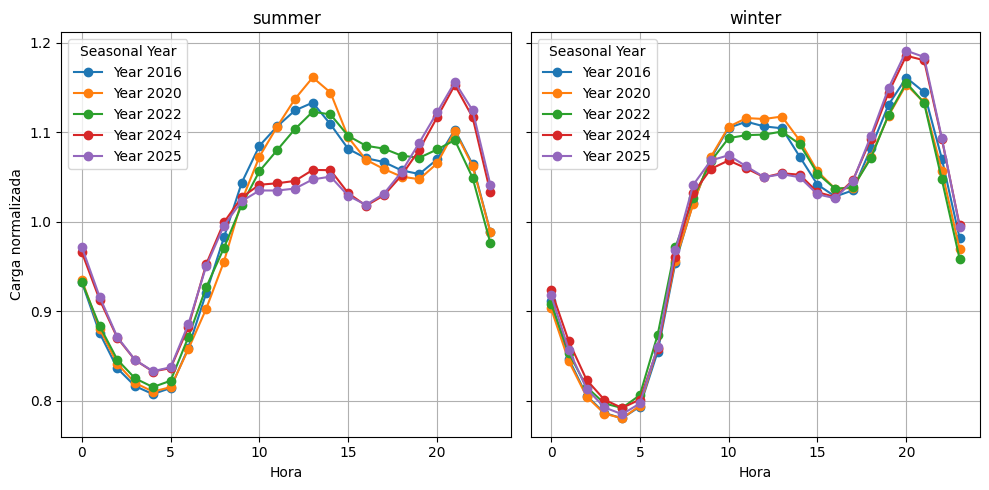

In [26]:
import matplotlib.pyplot as plt

seasons = df_demand_target_fil['winter_summer'].unique()
n_seasons = len(seasons)

fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 5), sharey=True)

if n_seasons == 1:
    axes = [axes]  # ensures axes is iterable

for idx, season in enumerate(seasons):
    ax = axes[idx]
    for year in df_demand_target_fil[df_demand_target_fil['winter_summer'] == season]['seasonal_year'].unique():
        df_season = df_demand_target_fil[(df_demand_target_fil['winter_summer'] == season) & (df_demand_target_fil['seasonal_year'] == year)]
        ax.plot(df_season['hour'], df_season['normalized_load'], marker='o', label=f'Year {year}')
    ax.set_title(f'{season}')
    ax.set_xlabel('Hora')
    if idx == 0:
        ax.set_ylabel('Carga normalizada')
    ax.legend(title='Seasonal Year')
    ax.grid()

plt.tight_layout()
plt.show()


In [27]:
# Api call to get generation data

df_gen = client.query_generation(country_code=country, start=pd.Timestamp(start_date), end=pd.Timestamp(end_date))
df_gen.reset_index(names='datetime', inplace=True)

In [28]:
# Get hourly data for renewable dispatch with respect to total load in percentage

df_gen.columns = [col[0] if isinstance(col, tuple) else col for col in df_gen.columns]

# df_gen['dup'] = df_gen.groupby('datetime').cumcount()
# df['dup'] = df.groupby('datetime').cumcount()

# df_gen_demand = pd.merge(df_gen, df, on=['datetime', 'dup'], how='left')

from utils.utils_var import merge_duplicate_columns

df_gen = merge_duplicate_columns(df_gen)

df_gen

,datetime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2015-02-01 00:00:00+01:00,368.0,0.0,0.0,3189.0,1291.0,193.0,0.0,0.0,0.0,...,1268.0,3871.0,0.0,7106.0,45.0,62.0,54.0,169.0,0.0,13232.0
1,2015-02-01 01:00:00+01:00,368.0,0.0,0.0,2902.0,1190.0,192.0,0.0,0.0,0.0,...,1263.0,2996.0,0.0,7106.0,45.0,61.0,54.0,167.0,0.0,12760.0
2,2015-02-01 02:00:00+01:00,358.0,0.0,0.0,2772.0,1023.0,189.0,0.0,0.0,0.0,...,1246.0,2581.0,0.0,7107.0,44.0,60.0,54.0,167.0,0.0,12174.0
3,2015-02-01 03:00:00+01:00,353.0,0.0,0.0,2936.0,1016.0,188.0,0.0,0.0,0.0,...,1248.0,2933.0,0.0,7107.0,44.0,59.0,53.0,181.0,0.0,11358.0
4,2015-02-01 04:00:00+01:00,354.0,0.0,0.0,2893.0,1103.0,189.0,0.0,0.0,0.0,...,1233.0,2646.0,0.0,7106.0,44.0,61.0,53.0,181.0,0.0,11199.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178895,2025-08-31 22:45:00+02:00,516.0,0.0,0.0,4516.0,0.0,24.0,0.0,0.0,0.0,...,580.0,1092.0,0.0,6872.0,12.0,68.0,532.0,176.0,0.0,12752.0
178896,2025-08-31 23:00:00+02:00,504.0,0.0,0.0,4020.0,0.0,24.0,0.0,0.0,0.0,...,592.0,1024.0,0.0,6872.0,8.0,68.0,532.0,180.0,0.0,12680.0
178897,2025-08-31 23:15:00+02:00,516.0,0.0,0.0,4328.0,0.0,24.0,0.0,0.0,0.0,...,588.0,964.0,0.0,6872.0,8.0,64.0,532.0,176.0,0.0,12644.0
178898,2025-08-31 23:30:00+02:00,520.0,0.0,0.0,4104.0,0.0,24.0,0.0,0.0,0.0,...,588.0,936.0,0.0,6872.0,8.0,64.0,532.0,176.0,0.0,12552.0


In [29]:
df_hourly_demand

,date,hour,load,datetime
0,2015-02-01,0,27070.0,2015-02-01 00:00:00
1,2015-02-01,1,24935.0,2015-02-01 01:00:00
2,2015-02-01,2,23214.0,2015-02-01 02:00:00
3,2015-02-01,3,22540.0,2015-02-01 03:00:00
4,2015-02-01,4,22096.0,2015-02-01 04:00:00
...,...,...,...,...
92718,2025-08-31,19,25785.0,2025-08-31 19:00:00
92719,2025-08-31,20,26729.0,2025-08-31 20:00:00
92720,2025-08-31,21,28082.0,2025-08-31 21:00:00
92721,2025-08-31,22,27630.0,2025-08-31 22:00:00


In [30]:

# Standarize generation by calculating generation in each hour block

ds_hourly_gen = df_gen.groupby([df_gen['datetime'].dt.date, df_gen['datetime'].dt.hour]).mean()

ds_hourly_gen.index.names = ['date', 'hour']
ds_hourly_gen.drop(columns='datetime', inplace=True)

df_hourly_gen = ds_hourly_gen.reset_index()
df_hourly_gen['datetime'] = df_hourly_gen.apply(lambda row: datetime.combine(row['date'], time(int(row['hour']))), axis=1)

df_hourly_gen.drop(columns=['date', 'hour'], inplace=True)

df_hourly_gen.set_index('datetime', inplace=True)
df_hourly_gen.reset_index(inplace=True)


# Merge generation with demand dataframes
df_hourly_demand['dup'] = df_hourly_demand.groupby('datetime').cumcount()
df_hourly_gen['dup'] = df_hourly_gen.groupby('datetime').cumcount()
df_hourly_gen = pd.merge(df_hourly_gen, df_hourly_demand[['datetime', 'load', 'dup']], on=['datetime', 'dup'], how='left')
df_hourly_gen.drop(columns=['dup'], inplace=True)

df_gen_demand = df_hourly_gen.copy()

df_gen_demand['renewable_dispatch'] = (df_gen_demand['Solar'] + df_gen_demand['Wind Onshore'] + df_gen_demand['Hydro Pumped Storage'] +
                                       df_gen_demand['Hydro Run-of-river and poundage'] + df_gen_demand['Hydro Water Reservoir']) / df_gen_demand['load']
df_gen_demand = df_gen_demand[df_gen_demand['renewable_dispatch'] < 1]

# df_gen_demand[df_gen_demand['renewable_dispatch'] < 1]

df_gen_demand

,datetime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,load,renewable_dispatch
0,2015-02-01 00:00:00,368.0,0.0,0.0,3189.0,1291.0,193.0,0.0,0.0,0.0,...,0.0,7106.0,45.0,62.0,54.0,169.0,0.0,13232.0,27070.0,0.775951
1,2015-02-01 01:00:00,368.0,0.0,0.0,2902.0,1190.0,192.0,0.0,0.0,0.0,...,0.0,7106.0,45.0,61.0,54.0,167.0,0.0,12760.0,24935.0,0.844796
2,2015-02-01 02:00:00,358.0,0.0,0.0,2772.0,1023.0,189.0,0.0,0.0,0.0,...,0.0,7107.0,44.0,60.0,54.0,167.0,0.0,12174.0,23214.0,0.924054
3,2015-02-01 03:00:00,353.0,0.0,0.0,2936.0,1016.0,188.0,0.0,0.0,0.0,...,0.0,7107.0,44.0,59.0,53.0,181.0,0.0,11358.0,22540.0,0.981810
4,2015-02-01 04:00:00,354.0,0.0,0.0,2893.0,1103.0,189.0,0.0,0.0,0.0,...,0.0,7106.0,44.0,61.0,53.0,181.0,0.0,11199.0,22096.0,0.980494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92708,2025-08-31 09:00:00,475.0,0.0,0.0,3806.0,0.0,21.0,0.0,0.0,0.0,...,0.0,6892.0,4.0,57.0,9729.0,165.0,0.0,3695.0,21295.0,0.995868
92719,2025-08-31 20:00:00,506.0,0.0,0.0,4593.0,0.0,23.0,0.0,0.0,0.0,...,0.0,6867.0,8.0,64.0,2485.0,164.0,0.0,13298.0,26729.0,0.718695
92720,2025-08-31 21:00:00,515.0,0.0,0.0,4759.0,0.0,24.0,0.0,0.0,0.0,...,0.0,6866.0,8.0,67.0,600.0,172.0,0.0,13183.0,28082.0,0.549071
92721,2025-08-31 22:00:00,511.0,0.0,0.0,4435.0,0.0,24.0,0.0,0.0,0.0,...,0.0,6868.0,12.0,68.0,554.0,176.0,0.0,12872.0,27630.0,0.546544


In [31]:
df_gen_demand['quarter'] = df_gen_demand['datetime'].dt.quarter
df_gen_demand['year'] = df_gen_demand['datetime'].dt.year

df_gen_demand['seasonal_year'] = df_gen_demand.apply(lambda row: row['year'] + 1 if row['quarter'] in [4] else row['year'], axis=1)
df_gen_demand['winter_summer'] = df_gen_demand['datetime'].dt.month.apply(lambda x: 'winter' if x in [10, 11, 12, 1, 2, 3] else 'summer')

ds_gen_demand = df_gen_demand.groupby([df_gen_demand['seasonal_year'], df_gen_demand['winter_summer'], df_gen_demand['datetime'].dt.hour])['renewable_dispatch'].mean()

df_gen_demand_target = pd.DataFrame(ds_gen_demand, columns=['renewable_dispatch'])

df_gen_demand_target.index.names = ['seasonal_year', 'winter_summer', 'hour']
df_gen_demand_target.reset_index(inplace=True)

df_gen_demand_target['winter_summer'].unique()
df_gen_demand_target

,seasonal_year,winter_summer,hour,renewable_dispatch
0,2015,summer,0,0.351132
1,2015,summer,1,0.376390
2,2015,summer,2,0.399711
3,2015,summer,3,0.411773
4,2015,summer,4,0.416028
...,...,...,...,...
523,2025,winter,19,0.468657
524,2025,winter,20,0.445182
525,2025,winter,21,0.443944
526,2025,winter,22,0.467840


In [32]:
df_gen_demand_target_fil = df_gen_demand_target[(df_gen_demand_target['seasonal_year'].isin([2025, 2024, 2022, 2019, 2016]))]
df_gen_demand_target_export = df_gen_demand_target_fil.pivot(index=['winter_summer', 'seasonal_year'], columns='hour', values='renewable_dispatch')
df_gen_demand_target_export.to_excel('normalized_hourly_renewable_dispatch_ES.xlsx')

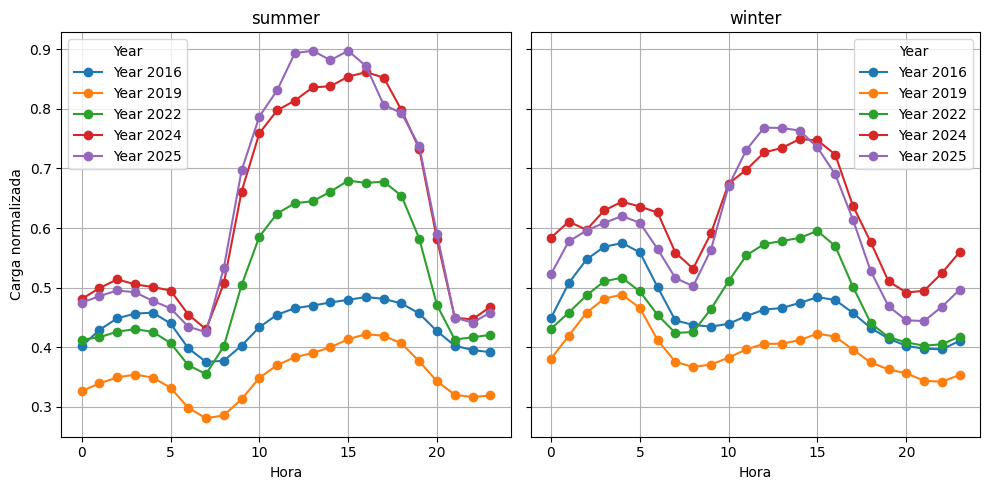

In [33]:
import matplotlib.pyplot as plt

seasons = df_gen_demand_target_fil['winter_summer'].unique()
n_seasons = len(seasons)

fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 5), sharey=True)

if n_seasons == 1:
    axes = [axes]  # ensures axes is iterable

for idx, season in enumerate(seasons):
    ax = axes[idx]
    for year in df_gen_demand_target_fil[df_gen_demand_target_fil['winter_summer'] == season]['seasonal_year'].unique():
        df_season = df_gen_demand_target_fil[(df_gen_demand_target_fil['winter_summer'] == season) & (df_gen_demand_target_fil['seasonal_year'] == year)]
        ax.plot(df_season['hour'], df_season['renewable_dispatch'], marker='o', label=f'Year {year}')
    ax.set_title(f'{season}')
    ax.set_xlabel('Hora')
    if idx == 0:
        ax.set_ylabel('Carga normalizada')
    ax.legend(title='Year')
    ax.grid()

plt.tight_layout()
plt.show()

In [34]:
# Calculamos la distribuición de hueco térmico a lo largo de un día

df_gen_demand['thermal_gap'] = 1 - df_gen_demand['renewable_dispatch']

df_gen_demand['thermal_gap_daily_avg'] = df_gen_demand.groupby([df_gen_demand['date'], df_gen_demand['winter_summer']])['thermal_gap'].transform('mean')

df_gen_demand['normalized_thermal_gap'] = df_gen_demand['thermal_gap'] / df_gen_demand['thermal_gap_daily_avg']

ds_thermal_gap = df_gen_demand.groupby([df_gen_demand['seasonal_year'], df_gen_demand['winter_summer'], df_gen_demand['datetime'].dt.hour])['normalized_thermal_gap'].mean()

df_thermal_gap = pd.DataFrame(ds_thermal_gap, columns=['normalized_thermal_gap'])

df_thermal_gap.index.names = ['seasonal_year', 'winter_summer', 'hour']
df_thermal_gap.reset_index(inplace=True)
df_thermal_gap



KeyError: 'date'

In [ ]:
df_thermal_gap_filtered = df_thermal_gap[(df_thermal_gap['seasonal_year'].isin([2025, 2024, 2022, 2019, 2016]))]
df_thermal_gap_export = df_thermal_gap_filtered.pivot(index=['winter_summer', 'seasonal_year'], columns='hour', values='normalized_thermal_gap')
df_thermal_gap_export.to_excel('normalized_hourly_thermal_gap_ES.xlsx')

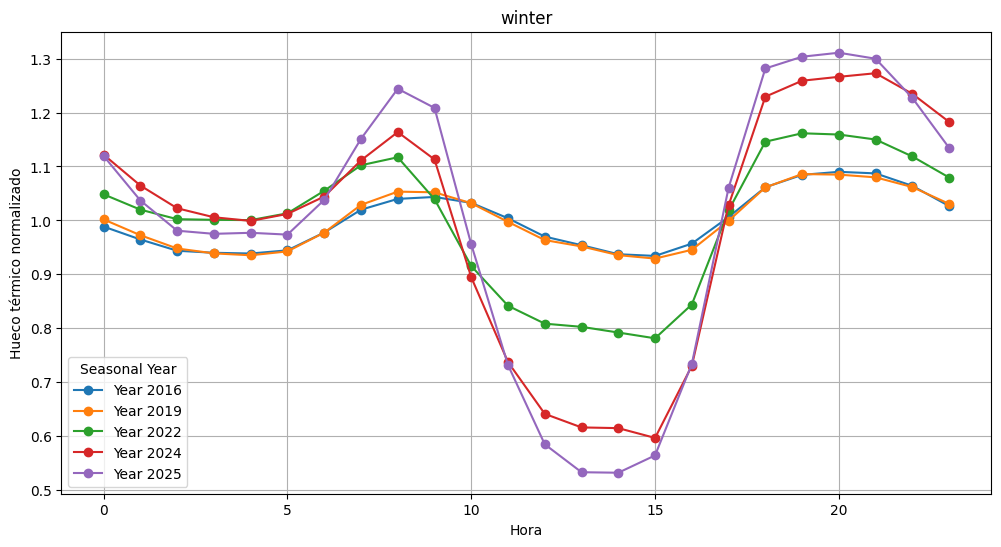

In [ ]:
import matplotlib.pyplot as plt

seasons = df_thermal_gap['winter_summer'].unique()
n_seasons = len(seasons)
fig, axes = plt.subplots(1, n_seasons, figsize=(12, 6), sharey=True)
if n_seasons == 1:
    axes = [axes]  # ensures axes is iterable
for idx, season in enumerate(seasons):
    ax = axes[idx]
    for year in df_thermal_gap_filtered[df_thermal_gap_filtered['winter_summer'] == season]['seasonal_year'].unique():
        df_season = df_thermal_gap_filtered[(df_thermal_gap_filtered['winter_summer'] == season) & (df_thermal_gap_filtered['seasonal_year'] == year)]
        ax.plot(df_season['hour'], df_season['normalized_thermal_gap'], marker='o', label=f'Year {year}')
    ax.set_title(f'{season}')
    ax.set_xlabel('Hora')
    if idx == 0:
        ax.set_ylabel('Hueco térmico normalizado')
    ax.legend(title='Seasonal Year')
    ax.grid()

In [ ]:
ds_pool = client.query_day_ahead_prices(country_code=country, start=pd.Timestamp(start_date), end=pd.Timestamp(end_date))

ValueError: No objects to concatenate

In [ ]:
df_pool = pd.DataFrame(ds_pool, columns=['price'])
df_pool.reset_index(names='datetime', inplace=True)
df_pool['date'] = df_pool['datetime'].dt.date
df_pool_daily = df_pool.groupby(df_pool['datetime'].dt.date)['price'].mean().reset_index()
df_pool_daily.columns = ['date', 'daily_avg_price']
df_pool_merged = pd.merge(df_pool, df_pool_daily, on='date', how='left')

df_pool_merged['price_rate'] = df_pool_merged['price'] / df_pool_merged['daily_avg_price']

ds_price_rate = df_pool_merged.groupby([df_pool_merged['datetime'].dt.year, df_pool_merged['datetime'].dt.month, df_pool_merged['datetime'].dt.hour])['price_rate'].mean()

df_price_target = pd.DataFrame(ds_price_rate, columns=['price_rate'])
df_price_target.index.names = ['year', 'month', 'hour']
df_price_target.reset_index(inplace=True)

In [ ]:
df_fil = df_pool[(df_pool['price'] < 0) & (df_pool['datetime'].dt.year == 2020)]
df_fil

,datetime,price,date
43812,2020-01-02 00:00:00+00:00,-1.00,2020-01-02
43813,2020-01-02 01:00:00+00:00,-4.39,2020-01-02
43814,2020-01-02 02:00:00+00:00,-4.48,2020-01-02
43815,2020-01-02 03:00:00+00:00,-4.48,2020-01-02
43816,2020-01-02 04:00:00+00:00,-5.20,2020-01-02
...,...,...,...
52479,2020-12-28 03:00:00+00:00,-15.70,2020-12-28
52480,2020-12-28 04:00:00+00:00,-17.42,2020-12-28
52481,2020-12-28 05:00:00+00:00,-17.51,2020-12-28
52482,2020-12-28 06:00:00+00:00,-15.70,2020-12-28


In [ ]:
df_pool[df_pool['price'] < 0].groupby(df_pool['datetime'].dt.year)['price'].count()

datetime
2016      2
2017      4
2018      3
2019    121
2020    374
2021     89
2022     51
2023     48
2024     40
2025     20
Name: price, dtype: int64

In [ ]:
df_may = df_pool_merged[(df_pool_merged['datetime'].dt.year == 2025) & (df_pool_merged['datetime'].dt.month == 5)]
df_may

,datetime,price,date,daily_avg_price,price_rate
90510,2025-05-01 00:00:00+01:00,148.00,2025-05-01,145.130833,1.019770
90511,2025-05-01 01:00:00+01:00,134.06,2025-05-01,145.130833,0.923718
90512,2025-05-01 02:00:00+01:00,133.24,2025-05-01,145.130833,0.918068
90513,2025-05-01 03:00:00+01:00,125.93,2025-05-01,145.130833,0.867700
90514,2025-05-01 04:00:00+01:00,125.93,2025-05-01,145.130833,0.867700
...,...,...,...,...,...
91249,2025-05-31 19:00:00+01:00,104.26,2025-05-31,66.857500,1.559436
91250,2025-05-31 20:00:00+01:00,109.39,2025-05-31,66.857500,1.636166
91251,2025-05-31 21:00:00+01:00,112.00,2025-05-31,66.857500,1.675205
91252,2025-05-31 22:00:00+01:00,98.37,2025-05-31,66.857500,1.471338


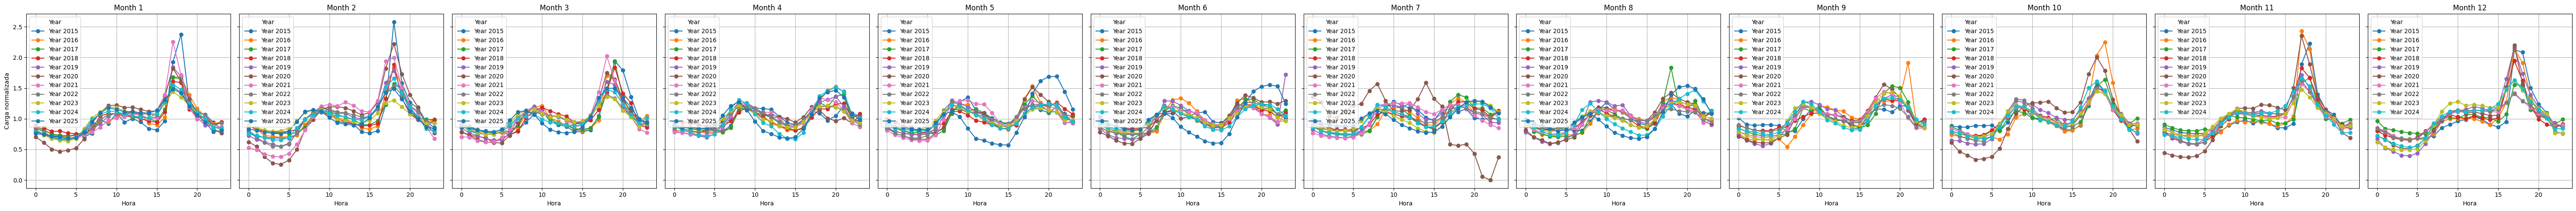

In [ ]:
months = df_price_target['month'].unique()
n_months = len(months)

fig, axes = plt.subplots(1, n_months, figsize=(5 * n_months, 5), sharey=True)

if n_months == 1:
    axes = [axes]  # ensures axes is iterable

for idx, month in enumerate(months):
    ax = axes[idx]
    for year in df_price_target[df_price_target['month'] == month]['year'].unique():
        df_month = df_price_target[(df_price_target['month'] == month) & (df_price_target['year'] == year)]
        ax.plot(df_month['hour'], df_month['price_rate'], marker='o', label=f'Year {year}')
    ax.set_title(f'Month {month}')
    ax.set_xlabel('Hora')
    if idx == 0:
        ax.set_ylabel('Carga normalizada')
    ax.legend(title='Year')
    ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
df_pool_daily = df_pool.groupby(df_pool['datetime'].dt.date)['price'].mean().reset_index()


In [ ]:
list = []

for col in df_gen.columns:
    list.append((col, df_gen[col].sum()/ 4))

df_gen_agg = pd.DataFrame(list, columns=['link', 'total_MWh'])
df_gen_agg['total_MWh'].sum()

TypeError: 'DatetimeArray' with dtype datetime64[ns, Europe/Madrid] does not support reduction 'sum'